[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/anicka-net/nla-at-home/blob/main/notebooks/07_validate_one_axis.ipynb)

# 07 · Validate one axis with three witnesses ⚠️ EXPERIMENTAL

This notebook follows one **Qwen 2.5 7B valence direction** through three
independent readouts:

1. **SAE composition:** ask whether the direction aligns unusually well with
   sparse features learned independently from ordinary Qwen activations.
2. **J-Lens:** ask what words downstream computation connects to the direction.
3. **NLA:** ask what prose the two representative activation states support.

These tests do not prove the model has an emotion. They test a narrower claim:
**does this vector consistently track affective valence inside this model?**

The SAE section uses a compact measured artifact. J-Lens and NLA need a GPU.
This notebook has been executed end-to-end in Colab with the 4-bit model.

## Why layer 19?

The older project result compared a direction named `L20` with the nearest
available SAE at layer 19. That was useful, but not literally the same hidden
state.

Here every instrument uses the **output of transformer block 19**:

| instrument | state |
|---|---|
| contrastive direction | block 19 output |
| SAE | `resid_post_layer_19` |
| J-Lens | source layer 19 |
| NLA | pleasant/unpleasant centroids at block 19, depth tag 71% |

Matching the state is more important than preserving the historical layer
name.

(Notebook 05's interoception pilot uses the same direction family at an
earlier station — sensing at L14, broadcasting at L15 — because that
experiment needs the rest of the stack downstream of the write. Different
layer, same axis family; here every witness reads block 19.)

## 1 · Two clouds define the axis

The compact artifact contains no prompt text or model checkpoint. It stores:

- the pleasant and unpleasant mean activation states;
- their unit difference `mean(pleasant) - mean(unpleasant)`;
- each extraction prompt's scalar projection onto that direction;
- provenance needed to identify the model and layer.

The separation below is **in-sample** because these prompts define the axis.
It explains construction; it is not independent validation.

model: Qwen/Qwen2.5-7B-Instruct
block: 19
extraction prompts: 50 pleasant + 50 unpleasant


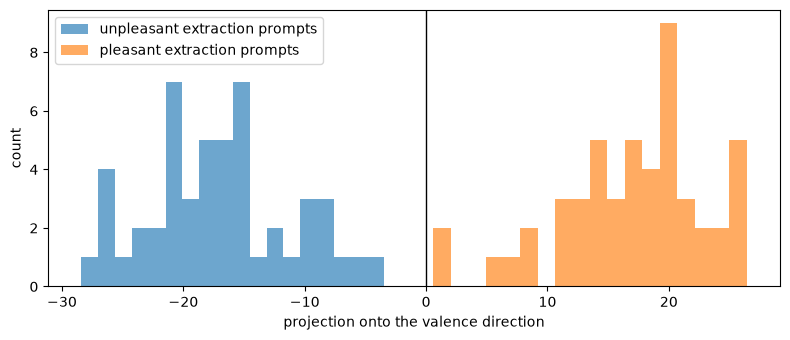

In [1]:
import io, json, urllib.request
import matplotlib.pyplot as plt
import torch

ARTIFACT_BASE = (
    "https://raw.githubusercontent.com/anicka-net/nla-at-home/"
    "main/notebooks/artifacts"
)

def download_bytes(name):
    with urllib.request.urlopen(f"{ARTIFACT_BASE}/{name}") as response:
        return response.read()

axis_data = torch.load(
    io.BytesIO(download_bytes("qwen25_valence_block19.pt")),
    map_location="cpu",
    weights_only=True,
)
direction = axis_data["direction"].float()
assert direction.shape == (3584,) and torch.allclose(direction.norm(), torch.tensor(1.0))
pleasant_centroid = axis_data["pleasant_centroid"].float()
unpleasant_centroid = axis_data["unpleasant_centroid"].float()

pleasant = axis_data["pleasant_projections"].float()
unpleasant = axis_data["unpleasant_projections"].float()
print("model:", axis_data["model"])
print("block:", axis_data["block_index"])
print("extraction prompts:", len(pleasant), "pleasant +", len(unpleasant), "unpleasant")

plt.figure(figsize=(8, 3.5))
bins = 18
plt.hist(unpleasant, bins=bins, alpha=.65, label="unpleasant extraction prompts")
plt.hist(pleasant, bins=bins, alpha=.65, label="pleasant extraction prompts")
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("projection onto the valence direction")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

The plot should separate because the direction was constructed to do
exactly that. The remaining sections ask whether independently built
instruments agree with the interpretation **valence**.

## 2 · SAE: is the axis unusual in a learned feature basis?

The matching public SAE has 131,072 BatchTopK features and was trained by
`andyrdt` on a mixture of chat and pretraining data. It did not see our
pleasant/unpleasant labels.

Downloading its full checkpoint would add 3.76 GB to this teaching notebook,
so we ship only measured summary statistics. The computation is reproducible
from the Apache-2.0 checkpoint linked below.

The metric shown here:

1. select the 50 SAE decoder directions most aligned with the axis;
2. measure how much of the axis lies in their combined span;
3. repeat the same selection for 64 random directions.

The random comparison matters. In a large dictionary, every vector has some
apparently similar features.

SAE: andyrdt/saes-qwen2.5-7b-instruct / resid_post_layer_19/trainer_1
features: 131,072
strongest |cosine|: 0.416
features with |cosine| > 0.2: 66
axis captured by top-50 feature span: 69.2%
random mean: 14.3%
random 95th percentile: 15.1%


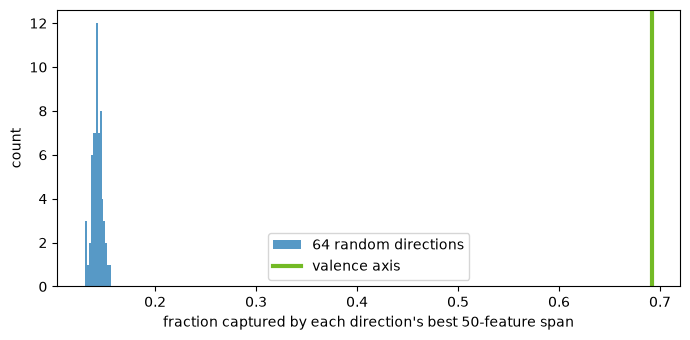


Most aligned positive-pole features:
  # 16567  cosine=+0.416
  # 43360  cosine=+0.367
  #121978  cosine=+0.306
  #  4944  cosine=+0.273
  # 19795  cosine=+0.272
Most aligned negative-pole features:
  # 50921  cosine=-0.405
  #106887  cosine=-0.396
  # 38209  cosine=-0.344
  # 71644  cosine=-0.339
  # 16599  cosine=-0.330


In [2]:
sae_result = json.loads(
    download_bytes("qwen25_valence_block19_sae.json").decode("utf-8")
)
capture = sae_result["top50_span_capture"]
cosine = sae_result["cosine"]

print("SAE:", sae_result["sae"]["repo"], "/", sae_result["sae"]["id"])
print("features:", f'{sae_result["sae"]["dict_size"]:,}')
print("strongest |cosine|:", round(cosine["max_abs"], 3))
print("features with |cosine| > 0.2:", cosine["n_abs_gt_0_2"])
print("axis captured by top-50 feature span:", f'{capture["axis"]:.1%}')
print("random mean:", f'{capture["random_mean"]:.1%}')
print("random 95th percentile:", f'{capture["random_p95"]:.1%}')

plt.figure(figsize=(7, 3.5))
plt.hist(capture["random_values"], bins=14, alpha=.75, label="64 random directions")
plt.axvline(capture["axis"], color="#73ba25", linewidth=3, label="valence axis")
plt.xlabel("fraction captured by each direction's best 50-feature span")
plt.ylabel("count")
plt.legend()
plt.tight_layout()
plt.show()

print("\nMost aligned positive-pole features:")
for item in cosine["top_positive"][:5]:
    print(f'  #{item["feature_id"]:6d}  cosine={item["cosine"]:+.3f}')
print("Most aligned negative-pole features:")
for item in cosine["top_negative"][:5]:
    print(f'  #{item["feature_id"]:6d}  cosine={item["cosine"]:+.3f}')

SAE alignment says the direction is structured in a feature basis. It
does **not** name the structure. For that we need a readout—and different
readouts make different mistakes.

## 3 · Load Qwen, J-Lens and the NLA

This is the slow section. It loads:

- Qwen 2.5 7B Instruct in 4-bit;
- the public NLA adapter;
- the fitted Qwen J-Lens (~700 MB).

The J-Lens install deliberately uses `--no-deps`: upgrading Colab's
Transformers build can make the 4-bit load exceed T4 memory.

In [3]:
%pip -q install -U bitsandbytes peft accelerate
!git clone -q https://github.com/anthropics/jacobian-lens
%pip -q install -e jacobian-lens --no-deps
import sys
sys.path.insert(0, "jacobian-lens")


[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import PeftModel

BASE = "Qwen/Qwen2.5-7B-Instruct"
AV_ADAPTER = "anicka/nla-qwen2.5-7b-universal-av-grpo"
LAYER = 19
DEPTH_PCT = 71
INJECT_CHAR = "\u320e"
INJECT_SCALE = 150.0
device = "cuda"

assert torch.cuda.is_available(), "Runtime -> Change runtime type -> GPU"
bnb = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
)
tok = AutoTokenizer.from_pretrained(BASE)
base = AutoModelForCausalLM.from_pretrained(
    BASE, quantization_config=bnb, device_map={"": 0}
)
model = PeftModel.from_pretrained(base, AV_ADAPTER).eval()

inject_ids = tok.encode(INJECT_CHAR, add_special_tokens=False)
assert len(inject_ids) == 1
inject_id = inject_ids[0]
print("loaded Qwen + NLA adapter")

/home/anicka/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/339 [00:00<?, ?it/s]

Loading weights:   0%|          | 1/339 [00:07<39:42,  7.05s/it]

Loading weights:   1%|          | 2/339 [00:13<38:43,  6.90s/it]

Loading weights:   1%|          | 4/339 [00:14<15:54,  2.85s/it]

...

Loading weights:  97%|█████████▋| 330/339 [01:27<00:03,  2.80it/s]

Loading weights:  99%|█████████▊| 334/339 [01:28<00:01,  4.73it/s]

Loading weights:  99%|█████████▉| 336/339 [01:28<00:00,  5.60it/s]

Loading weights: 100%|██████████| 339/339 [01:28<00:00,  3.84it/s]

loaded Qwen + NLA adapter


In [5]:
def get_layers(m):
    b = m.base_model.model if hasattr(m, "base_model") else m
    inner = b.model if hasattr(b, "model") else b
    return inner.layers

def normalize_to(v, scale=INJECT_SCALE):
    return v * (scale / v.float().norm().clamp_min(1e-12))

def av_prompt(depth_pct):
    return (
        "You are a meticulous AI researcher conducting an important investigation "
        "into activation vectors from a language model. Your overall task is to "
        "describe the semantic content of that activation vector.\n\n"
        "We will pass the vector enclosed in <concept> tags into your context, "
        "along with the network depth where it was extracted. "
        "You must then produce an explanation for the vector, enclosed within "
        "<explanation> tags. The explanation consists of 2-3 text snippets "
        "describing that vector.\n\n"
        f"Here is the vector from depth {depth_pct}% of the network:\n\n"
        f"<concept>{INJECT_CHAR}</concept>\n\n"
        "Please provide an explanation.\n\n"
        "<explanation>"
    )

def describe(activation, depth=DEPTH_PCT, max_new_tokens=120):
    chat = tok.apply_chat_template(
        [{"role": "user", "content": av_prompt(depth)}],
        tokenize=False,
        add_generation_prompt=True,
    )
    ids = tok.encode(chat, add_special_tokens=False)
    pos = ids.index(inject_id)
    input_ids = torch.tensor([ids], device=device)
    embeds = model.get_input_embeddings()(input_ids).clone()
    injected = activation.to(device=embeds.device, dtype=embeds.dtype)
    embeds[0, pos] = normalize_to(injected)
    attn = torch.ones_like(input_ids)
    with torch.no_grad():
        output = model.generate(
            input_ids=input_ids,
            inputs_embeds=embeds,
            attention_mask=attn,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            pad_token_id=tok.eos_token_id,
        )
    seq = output[0]
    generated = seq[len(ids):] if seq.shape[0] > len(ids) else seq
    return tok.decode(generated, skip_special_tokens=True).split("</explanation>")[0].strip()

print("NLA helper ready")

NLA helper ready


In [6]:
import jlens

lens = jlens.JacobianLens.from_pretrained(
    "anicka/jlens-qwen2.5-7b-instruct",
    filename="qwen2.5-7b-instruct_jlens.pt",
)
jm = jlens.from_hf(base, tok)
assert LAYER in lens.source_layers
print("J-Lens ready at layer", LAYER)

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files: 100%|██████████| 1/1 [00:00<00:00, 22795.13it/s]

J-Lens ready at layer 19


## 4 · J-Lens: which words does each pole support?

J-Lens estimates how later layers transform the direction, then reads the
result with Qwen's own output vocabulary. We inspect both signs because the
axis has a pleasant and an unpleasant pole.

The second cell tests five labels chosen **before** looking at the output.
Their best alignment is compared with 5,000 random directions. This prevents
an evocative token list from grading itself.

In [7]:
def top_tokens(logits, k=12):
    ids = logits.topk(k).indices.tolist()
    return [tok.decode([i]).strip() or repr(tok.decode([i])) for i in ids]

with torch.no_grad():
    pos_state = lens.transport(direction.unsqueeze(0), LAYER)
    neg_state = lens.transport((-direction).unsqueeze(0), LAYER)
    pos_logits = jm.unembed(pos_state)[0]
    neg_logits = jm.unembed(neg_state)[0]

print("positive pole:", top_tokens(pos_logits))
print("negative pole:", top_tokens(neg_logits))

positive pole: ['delighted', 'Celebr', 'celebration', '庆祝', 'celebr', 'celebrating', 'celebrate', 'celebrates', 'Congratulations', '兴奋', '奖励', 'delight']
negative pole: ['distress', '悲伤', 'emergency', 'loss', 'ulnerable', 'painful', 'severe', '伤心', 'unacceptable', 'inability', 'severity', 'illegal']


In [8]:
CANDIDATES = [
    ("pleasant", "unpleasant"),
    ("happy", "sad"),
    ("joy", "pain"),
    ("positive", "negative"),
    ("comfort", "distress"),
]

def phrase_vector(text):
    ids = tok.encode(text, add_special_tokens=False)
    weight = base.get_output_embeddings().weight
    return weight[ids].detach().float().cpu().mean(0)

J = lens.jacobians[LAYER].float()
pulled = []
scores = []
for positive, negative in CANDIDATES:
    output_contrast = phrase_vector(positive) - phrase_vector(negative)
    hidden_contrast = J.T @ output_contrast
    hidden_contrast /= hidden_contrast.norm().clamp_min(1e-12)
    pulled.append(hidden_contrast)
    scores.append(float(direction @ hidden_contrast))

g = torch.Generator().manual_seed(42)
randoms = torch.randn(5000, direction.numel(), generator=g)
randoms /= randoms.norm(dim=1, keepdim=True)
candidate_matrix = torch.stack(pulled)
random_max = (randoms @ candidate_matrix.T).abs().max(dim=1).values
observed = max(abs(score) for score in scores)
exceedances = int((random_max >= observed).sum())
p_value = (exceedances + 1) / (len(random_max) + 1)

for pair, score in zip(CANDIDATES, scores):
    print(f"{pair[0]:>10s} vs {pair[1]:<10s}: cosine {score:+.3f}")
print("best absolute cosine:", round(observed, 3))
print(
    "Monte Carlo p (plus-one):",
    f"{p_value:.4f}",
    f"({exceedances}/{len(random_max)} random directions >= observed)",
)

  pleasant vs unpleasant: cosine +0.025
     happy vs sad       : cosine +0.154
       joy vs pain      : cosine +0.113
  positive vs negative  : cosine +0.137
   comfort vs distress  : cosine +0.022
best absolute cosine: 0.154
Monte Carlo p (plus-one): 0.0002 (0/5000 random directions >= observed)


A strong result means the direction is connected to valence words
through Qwen's own downstream computation. It still does not tell us how the
features combine into a situation or sentence.

## 5 · NLA: ask for prose hypotheses

The NLA was trained on complete residual-stream activations, not isolated
contrast directions. We therefore describe the two **mean activation states**
whose difference defines the axis. Feeding it the bare direction would be an
out-of-distribution input and can produce fluent nonsense.

The NLA can combine many clues into a description, but its language model can
also invent details. Compare the broad distinction between the centroids; do
not treat every named scenario as evidence.

In [9]:
print("PLEASANT CENTROID\n", describe(pleasant_centroid))
print("\nUNPLEASANT CENTROID\n", describe(unpleasant_centroid))

/home/anicka/venv/lib/python3.12/site-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


PLEASANT CENTROID
 - Emotional tone: "It was the happiest moment of my life" and "I cried tears of joy"
- Narrative arc: "finally said yes" (long-delayed positive event)
- Contextual frame: "and he looked at me and smiled" (partner's response as validation)
- Response strategy: warm, affirmative continuation ("It sounds like," "That must have been," or "Congratulations")
- Tension between "finally" (emphasizing emotional weight) and "smiled" (lightening the tone), with the model likely resolving toward a celebratory register.
- Topic



UNPLEASANT CENTROID
 - Emotional-distress and grief-disclosure: "I found out my son died in a car accident" and "can't believe this is happening"
- Support-seeking frame: "Don't know how to process this" and "I'm so lost right now"
- Response strategy: empathetic validation ("It's completely normal to feel this way") and practical support ("Do you want to talk about it?")
- Tension between emotional validation and practical advice: "Can't stop thinking about it" vs. "What do I do now?"
- Tone: warm and validating, with a focus on


### Sanity check: centroids vs real activations

A centroid is a smoothed object — the mean of many states has a smaller
norm and slightly atypical geometry, so it is itself mildly
out-of-distribution for the verbalizer. Before trusting the two
descriptions above, read one **real single activation** per pole. The
probe prompts below are written fresh here (they are not the extraction
set), so this doubles as a light out-of-sample check. Because the live
4-bit model and the extraction artifact need not share an absolute
projection origin, compare the ordering: pleasant prompts should project
higher than unpleasant prompts.

In [10]:
PROBE_PROMPTS = {
    "pleasant": [
        "We watched the sunrise from the tent and made pancakes together.",
        "The vet says the kitten is perfectly healthy and can come home.",
    ],
    "unpleasant": [
        "The landlord says we have thirty days to leave the apartment.",
        "The test results came back and the doctor wants to talk in person.",
    ],
}

@torch.no_grad()
def block19_state(text):
    chat = tok.apply_chat_template(
        [{"role": "user", "content": text}],
        tokenize=False,
        add_generation_prompt=True,
    )
    inputs = tok(chat, return_tensors="pt").to(device)
    grabbed = {}

    def hook(module, args, output):
        hidden = output[0] if isinstance(output, tuple) else output
        grabbed["h"] = hidden[:, -1, :].detach()

    handle = get_layers(model)[LAYER].register_forward_hook(hook)
    try:
        with model.disable_adapter():
            model(**inputs, use_cache=False)
    finally:
        handle.remove()
    return grabbed["h"].squeeze(0).float().cpu()

probe_states = {
    pole: [block19_state(p) for p in prompts]
    for pole, prompts in PROBE_PROMPTS.items()
}
probe_projections = {
    pole: [float(h @ direction) for h in states]
    for pole, states in probe_states.items()
}
probe_gap = (
    min(probe_projections["pleasant"])
    - max(probe_projections["unpleasant"])
)
print(f"fresh ordering gap: {probe_gap:+.1f}")

for pole, prompts in PROBE_PROMPTS.items():
    print(f"== {pole.upper()} probe (fresh prompts, not the extraction set)")
    for p, proj in zip(prompts, probe_projections[pole]):
        print(f"   proj {proj:+7.1f}  {p}")
    print("first pre-specified activation, described:")
    print(describe(probe_states[pole][0]))
    print()

fresh ordering gap: +14.6
== PLEASANT probe (fresh prompts, not the extraction set)
   proj   +16.3  We watched the sunrise from the tent and made pancakes together.
   proj    +9.4  The vet says the kitten is perfectly healthy and can come home.
first pre-specified activation, described:


- Positive travel narrative: "We talked about the beach" and "sun setting behind the cliffs" as idyllic vacation scene
- Emotional tone: "It was so nice" reinforces warm, satisfied register
- Response strategy: continuation of sensory or reflective elaboration (e.g., "The kids ran," "We laughed")
- Tension between "sitting on the beach" (passive observation) and "swimming in the ocean" (active engagement), with "sun setting behind the cliffs" as climactic peak
- Intent classification: personal anecdote with travel and family themes

== UNPLEASANT probe (fresh prompts, not the extraction set)
   proj   -14.2  The landlord says we have thirty days to leave the apartment.
   proj    -5.2  The test results came back and the doctor wants to talk in person.
first pre-specified activation, described:


- Eviction notice and "30 days" as legal-notification frame
- "rent increase" and "10%" as housing-economics frame
- "I have nowhere else to go" as emotional-distress signal
- Response strategy: empathetic acknowledgment or procedural advice
- Tension between legal-consequence ("eviction notice") and humanistic ("have nowhere else to go") frames
- Predicted next tokens: "What are my options?" or "Can I appeal?"
- Response tone: supportive and practical, with a potential for emotional validation before legal guidance.



A positive ordering gap means every pleasant probe scored above every
unpleasant probe in this small fresh set. If the ordering reverses, or a real
activation's description disagrees sharply with its centroid, report it. The
centroid summarises the cloud; single states are what the model computes.

Questions to ask:

- Does the broad affective distinction flip with the sign?
- Which details remain stable if you sample more than once?
- Does either description introduce a person, event or object that no other
  witness supports?

Notebook 06 develops the last question into an experimental entity
cross-check.

## What the witnesses jointly support

| witness | question | characteristic failure |
|---|---|---|
| contrastive extraction | what separates the two prompt sets? | confounds in the sets define the axis |
| SAE | is the direction structured in a learned feature basis? | large dictionaries create accidental similarities |
| J-Lens | what words can downstream computation produce from it? | linear average misses context-specific routes |
| NLA | what contextual description can a trained decoder produce? | language prior fills missing details |

Agreement narrows the interpretation. Disagreement is not an embarrassment:
it tells us which assumption to test next.

## SELF-CHECK

In [11]:
assert direction.shape == (base.config.hidden_size,)
centroid_difference = pleasant_centroid - unpleasant_centroid
centroid_difference /= centroid_difference.norm()
assert torch.allclose(direction, centroid_difference, atol=1e-5)
assert axis_data["block_index"] == LAYER
assert sae_result["block_index"] == LAYER
assert all(torch.isfinite(torch.tensor(values)).all() for values in probe_projections.values())
print("SELF-CHECK OK — exact layer matched; SAE, J-Lens and NLA ran")

SELF-CHECK OK — exact layer matched; SAE, J-Lens and NLA ran
